# Algoritmo genético para optimización de hiperparámetros

## Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import random
import copy
import time
import tracemalloc
import concurrent.futures
from dataclasses import dataclass
from IPython.display import display
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

## Representación de un individuo

In [ ]:
@dataclass
class Individual:
    """
    Representa el conjunto de hiperparámetros de un modelo de Random Forest junto con su fitness asociado.
    """
    # Genes
    n_estimators: int            # 10-300
    max_depth: int               # 2-30
    min_samples_split: int       # 2-20
    min_samples_leaf: int        # 1-20
    max_features: float          # 0.1-1.0
    bootstrap: int               # 0/1
    criterion: int               # 0=gini, 1=entropy
    class_weight: int            # 0=None, 1=balanced
    max_leaf_nodes: int          # 10-200
    min_impurity_decrease: float # 0-0.1

    fitness: float = None

    def to_list(self):
        return [
            self.n_estimators, self.max_depth, self.min_samples_split,
            self.min_samples_leaf, self.max_features, self.bootstrap,
            self.criterion, self.class_weight, self.max_leaf_nodes,
            self.min_impurity_decrease
        ]

    def genes_dict(self):
        """Devuelve un diccionario con los genes, excluyendo el fitness."""
        # vars(self) devuelve el diccionario interno del objeto
        genes_dict = vars(self).copy()
        genes_dict.pop('fitness', None)
        return genes_dict

## Generar un individuo

In [ ]:
def create_random_individual() -> Individual:
    """Genera un individuo aleatorio con un rangos específicos para cada parámetro (gen)"""
    return Individual(
        n_estimators=random.randint(10, 300),           # Entero, rango 10-300
        max_depth=random.randint(2, 30),                # Entero, rango 2-30
        min_samples_split=random.randint(2, 20),        # Entero, rango 2-20
        min_samples_leaf=random.randint(1, 20),         # Entero, rango 1-20
        max_features=random.uniform(0.1, 1.0),          # Real, rango 0.1-1.0
        bootstrap=random.randint(0, 1),                 # Binario, 0/1
        criterion=random.randint(0, 1),                 # Categórico, 0=gini, 1=entropy
        class_weight=random.randint(0, 1),              # Binario, 0=None, 1=balanced
        max_leaf_nodes=random.randint(10, 200),         # Entero, rango 10-200
        min_impurity_decrease=random.uniform(0, 0.1)    # Real, rango 0-0.1
    )

## Generar población inicial

In [ ]:
def initialize_population(pop_size: int) -> list[Individual]:
    """
    Inicializar población de forma aleatoria.

    Args:
        pop_size: Tamaño de la población.

    Returns:
        list[Individual]: Lista de individuos.
    """
    return [create_random_individual() for _ in range(pop_size)]

## Evaluar población

In [ ]:
def evaluate_population(population: list[Individual]) -> list[float]:
    tiempos_evaluacion = []
    total = len(population)

    # Identificamos quiénes necesitan evaluación real (fitness is None)
    indices_a_evaluar = [i for i, ind in enumerate(population) if ind.fitness is None]

    if not indices_a_evaluar:
        return [0.0] * total

    for i in indices_a_evaluar:
        individual = population[i]
        # Solo evaluamos si es un individuo nuevo
        params = individual.to_list()
        start_time = time.perf_counter()
        individual.fitness = evaluate_solution(params)
        end_time = time.perf_counter()

        duracion = end_time - start_time
        tiempos_evaluacion.append(duracion)

        # Print de progreso dinámico
        print(f"\r  > Progreso Evaluación: [{len(tiempos_evaluacion)}/{len(indices_a_evaluar)}] ", end='', flush=True)
        print(f"Tiempo del individuo: {duracion:.2f}s", end='', flush=True)

    return tiempos_evaluacion

## Operador de selección

In [ ]:
def stochastic_universal_sampling(population: list[Individual], num_to_select: int) -> list[Individual]:
    """Operador de seleccion por muestreo estocástico universal"""
    total_fitness = sum(ind.fitness for ind in population)      # Suma total de las precisiones medias
    distance = total_fitness / num_to_select                    # Distancia fija entre los punteros de selección
    pointer = random.uniform(0, distance)                       # Punto de inicio aleatorio para el primer puntero

    selected_parents = []                                       # Lista para almacenar los individuos elegidos
    cumulative_fitness = 0                                      # Acumulador de fitness para la ruleta
    idx = 0                                                     # Índice para recorrer los objetos Individual

    for _ in range(num_to_select):                              # Bucle para realizar cada selección necesaria
        while cumulative_fitness < pointer:                     # Avanzar por la población hasta alcanzar el puntero
            cumulative_fitness += population[idx].fitness       # Sumar el fitness del individuo actual
            idx += 1                                            # Incrementar índice para evaluar al siguiente

        selected_parents.append(population[idx - 1])            # Añadir el individuo que coincide con el puntero
        pointer += distance                                     # Desplazar el puntero a la siguiente posición fija

    return selected_parents                                     # Devolver los padres que participarán en el cruce

## Operador de cruce

In [ ]:
def uniform_crossover(parent1: Individual, parent2: Individual) -> tuple[Individual, Individual]:
    """Realiza un cruce uniforme entre dos padres"""
    child1_genes = {}
    child2_genes = {}

    # Obtenemos los diccionarios de genes de ambos padres
    p1_genes = parent1.genes_dict()
    p2_genes = parent2.genes_dict()

    # Iteramos directamente sobre las claves (los nombres de los genes)
    for gen_name in p1_genes.keys():
        if random.random() < 0.5:
            child1_genes[gen_name] = p1_genes[gen_name]
            child2_genes[gen_name] = p2_genes[gen_name]
        else:
            child1_genes[gen_name] = p2_genes[gen_name]
            child2_genes[gen_name] = p1_genes[gen_name]

    # Instanciar los hijos
    return Individual(**child1_genes), Individual(**child2_genes)

## Operador de mutación

In [ ]:
def mutate(individual: Individual, mutation_rate: float = 0.1) -> None:
    """
    Aplica mutación uniforme iterando dinámicamente sobre los genes.
    """
    # Generar un individuo aleatorio
    donante = create_random_individual()

    # Obtener lista de genes
    genes = individual.genes_dict().keys()

    # 3. Iteramos con un solo bucle
    for gen_name in genes:
        if random.random() < mutation_rate:
            # Si el gen muta, extraer el valor del donante y sobreescribir
            nuevo_valor = getattr(donante, gen_name)
            setattr(individual, gen_name, nuevo_valor)

## Función de Fitness

In [ ]:
def evaluate_solution(params):

    # Configuración del modelo con parámetros formateados
    model = RandomForestClassifier(
        n_estimators           = int(params[0]),
        max_depth              = int(params[1]),
        min_samples_split      = int(params[2]),
        min_samples_leaf       = int(params[3]),
        max_features           = float(params[4]),
        bootstrap              = bool(params[5]),
        criterion              = "gini" if params[6] == 0 else "entropy",
        class_weight           = None if params[7] == 0 else "balanced",
        max_leaf_nodes         = int(params[8]),
        min_impurity_decrease  = float(params[9]),
        random_state=42,
        n_jobs=-1
    )

    # Validación cruzada
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

    return scores.mean()

## Algoritmo genético

In [ ]:
def genetic_algorithm(pop_size: int, n_generations: int, alpha: float, beta: float, elite_size: int):
    population = initialize_population(pop_size)
    elite_fitness_history = []
    population_avg_history = []
    eval_times_history = []

    for gen in range(n_generations):
        # 1. EVALUAR: Solo se evalúan los que tienen fitness None (los hijos nuevos)
        eval_times = evaluate_population(population)

        eval_times_history.append(eval_times)

        # 2. SELECCIÓN DE ÉLITE O(N)
        temp_pop = list(population)
        current_elite = []
        for _ in range(elite_size):
            if not temp_pop: break
            m = max(temp_pop, key=lambda x: x.fitness)
            current_elite.append(m)
            temp_pop.remove(m)

        # 3. GUARDAR ESTADÍSTICAS
        elite_fitnesses = [ind.fitness for ind in current_elite]
        pop_avg_fitness = sum(ind.fitness for ind in population) / pop_size

        elite_fitness_history.append(elite_fitnesses)
        population_avg_history.append(pop_avg_fitness)

        print(f"Gen {gen}: Mejor = {elite_fitnesses[0]:.4f} | Media = {pop_avg_fitness:.4f}")

        # --- SALIDA ANTICIPADA ---
        # Si es la última generación, ya tenemos la élite y las stats. No creamos más hijos.
        if gen == n_generations - 1:
            break

        # --- REPRODUCCIÓN (Solo ocurre si no es la última gen) ---
        new_population = [copy.deepcopy(ind) for ind in current_elite]
        num_parents_needed = pop_size - elite_size
        parents = stochastic_universal_sampling(population, num_parents_needed)

        for i in range(0, len(parents), 2):
            p1, p2 = parents[i], parents[(i + 1) % len(parents)]
            if random.random() < alpha:
                h1, h2 = uniform_crossover(p1, p2)
            else:
                h1, h2 = copy.deepcopy(p1), copy.deepcopy(p2)

            mutate(h1, beta)
            mutate(h2, beta)

            # Marcamos para evaluar en la siguiente iteración
            h1.fitness, h2.fitness = None, None

            if len(new_population) < pop_size: new_population.append(h1)
            if len(new_population) < pop_size: new_population.append(h2)

        population = new_population

    # Devolvemos la élite calculada en la última iteración válida
    return current_elite, elite_fitness_history, population_avg_history, eval_times_history

## Random Search

In [ ]:
def random_search(pop_size: int, iterations: int):
    """
    Algoritmo de Búsqueda Aleatoria (Random Search).
    Estructurado en "poblaciones" y "generaciones" para mantener
    la nomenclatura exacta y comparar limpiamente con el Algoritmo Genético.
    """

    global_best_history = []
    pop_avg_history = []
    eval_times_history = []

    global_best_fitness = 0.0
    best_individual = None

    for it in range(iterations):
        # 1. Generar una población nueva puramente aleatoria
        current_population = initialize_population(pop_size)

        # 2. Evaluar
        eval_times = evaluate_population(current_population)

        eval_times_history.append(eval_times)

        # 3. Encontrar el mejor de la generación actual
        current_best = max(current_population, key=lambda x: x.fitness)

        # 4. Actualizar el campeón global si hemos encontrado uno mejor
        if current_best.fitness > global_best_fitness:
            global_best_fitness = current_best.fitness
            best_individual = copy.deepcopy(current_best)

        # 5. Calcular la media de esta población aleatoria
        pop_avg_fitness = sum(ind.fitness for ind in current_population) / pop_size

        print("Average Evaluation Time:", np.mean(eval_times))

        # Guardar historiales
        global_best_history.append([global_best_fitness])
        pop_avg_history.append(pop_avg_fitness)

        print(f"Iteracion {it}: Mejor Histórico = {global_best_fitness:.4f} | Mejor Actual = {current_best.fitness:.4f} | Media Población = {pop_avg_fitness:.4f}")

    return best_individual, global_best_history, pop_avg_history, eval_times_history

## Grid Search

In [ ]:
def grid_search(X, y, param_grid):
    # 1. Instanciar y configurar
    rf = RandomForestClassifier(random_state=42)

    gs = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=2
    )

    # 2. Entrenar
    gs.fit(X, y)

    # 3. Extraer el "Individuo Mejor" (formatear los genes)
    bp = gs.best_params_

    # Mapeamos los valores categóricos/binarios a números
    mejor_individuo = [
        bp['n_estimators'],
        bp['max_depth'],
        bp['min_samples_split'],
        bp['min_samples_leaf'],
        bp['max_features'],
        1 if bp['bootstrap'] else 0,
        0 if bp['criterion'] == 'gini' else 1,
        0 if bp['class_weight'] is None else 1,
        bp['max_leaf_nodes'],
        bp['min_impurity_decrease']
    ]

    # Devolvemos el score y la lista de genes (el individuo)
    return gs.best_score_, mejor_individuo

## Método experimental

In [ ]:
def execute_experiments(algorithm_func, n_runs: int, *args, **kwargs):
    """
    Motor universal para ejecutar N experimentos de cualquier algoritmo.

    Args:
        algorithm_func: La función del algoritmo a evaluar (genetic_algorithm o random_search).
        n_runs: Número de ejecuciones.
        *args, **kwargs: Todos los parámetros que requiera tu algoritmo específico.
    """
    cpu_time_list = []
    memory_list_mb = []

    # Listas genéricas para guardar los 3 retornos de tus algoritmos
    all_primary_results = [] # Aquí irá el elite_final o el best_ind
    all_histories_1 = []     # Aquí irá el historial de la élite o el historial del mejor
    all_histories_2 = []     # Aquí irá el historial de la población
    all_eval_times = []      # Historial de tiempos de evaluacion

    # Extraemos el nombre de la función para que los prints queden profesionales
    algo_name = algorithm_func.__name__

    for i in range(n_runs):
        print(f">> Iniciando experimento {i+1}/{n_runs} [{algo_name}]...")

        # 1. Iniciar medición
        tracemalloc.start()
        start_time = time.perf_counter()

        # 2. Ejecutar el algoritmo de forma dinámica
        # Pasa todos los argumentos extra directamente a la función que toque
        res_primary, hist1, hist2, eval_times = algorithm_func(*args, **kwargs)

        # 3. Terminar medición
        end_time = time.perf_counter()
        _, peak_mem = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        # 4. Procesar métricas
        execution_time = end_time - start_time
        peak_mem_mb = peak_mem / (1024 * 1024)

        print(f"<< Experimento {i+1} terminado | CPU: {execution_time:.2f}s | RAM Pico: {peak_mem_mb:.2f} MB")

        # 5. Guardar historiales
        cpu_time_list.append(execution_time)
        memory_list_mb.append(peak_mem_mb)

        all_primary_results.append(res_primary)
        all_histories_1.append(hist1)
        all_histories_2.append(hist2)

        all_eval_times.append(eval_times)

    return (
        cpu_time_list,
        memory_list_mb,
        all_primary_results,
        all_histories_1,
        all_histories_2,
        all_eval_times
    )

### Conjunto de datos

Cargamos y representamos las distintas series temporales que conforman el problema:

In [ ]:
#data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
data = pd.read_csv('https://raw.githubusercontent.com/Shrondi/metaheuristicas/refs/heads/main/data/p2/winequality-red.csv', sep=',')

In [ ]:
# Convertir problema a clasificación binaria
data["quality"] = (data["quality"] >= 6).astype(int)

X = data.drop("quality", axis=1)
y = data["quality"]

### Grid Search

In [ ]:
def execute_experiment_gs(p_grid):
    """
    Ejecuta el Grid Search midiendo tiempo real y consumo de memoria.
    """
    print(f"Iniciando Grid Search...")

    # --- INICIO DE MEDICIÓN ---
    tracemalloc.start()
    start_time = time.perf_counter()

    resultado, mejor_ind = grid_search(X, y, p_grid)

    # --- FIN DE MEDICIÓN ---
    end_time = time.perf_counter()
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # Cálculo de métricas
    tiempo_total = end_time - start_time
    memoria_pico = peak / (1024 * 1024)

    return resultado, mejor_ind, tiempo_total, memoria_pico

Configurar una rejilla usando 2 valores discretos para aquellos hiperparámetros de tipo real y otra otra rejilla usando 3 valores discretos:

In [ ]:
param_grid_1 = {
    'n_estimators': [10, 300],
    'max_depth': [2, 30],
    'min_samples_split': [2, 20],
    'min_samples_leaf': [1, 20],
    'max_features': [0.1, 1.0],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced'],
    'max_leaf_nodes': [10, 200],
    'min_impurity_decrease': [0, 0.1]
}

In [ ]:
param_grid_2 = {
    'n_estimators': [10, 150, 300],
    'max_depth': [2, 15, 30],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 10, 20],
    'max_features': [0.1, 0.5, 1.0],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced'],
    'max_leaf_nodes': [10, 150, 200],
    'min_impurity_decrease': [0, 0.05, 0.1]
}

Ejecutar experimentos usando las rejilla anteriormente definidas:

In [ ]:
best_result_gs_1, best_ind_gs_1, cpu_time_gs_1, memory_gs_1 = execute_experiment_gs(param_grid_1)

Iniciando Grid Search...
Fitting 5 folds for each of 1024 candidates, totalling 5120 fits


In [ ]:
best_result_gs_2, best_ind_gs_2, cpu_time_gs_2, memory_gs_2 = execute_experiment_gs(param_grid_1)

Iniciando Grid Search...
Fitting 5 folds for each of 17496 candidates, totalling 87480 fits


Los resultados obtenidos usando la rejilla 1 son:

In [ ]:
print(f"CPU: {cpu_time_gs_1:.2f}s | RAM Pico: {memory_gs_1:.2f} MB")

CPU: 435.89s | RAM Pico: 6.10 MB


In [ ]:
print(best_result_gs_1)

0.7417241379310345


In [ ]:
print(best_ind_gs_1)

[10, 30, 2, 20, 1.0, 1, 1, 0, 200, 0]


Los nuevos valores obtenidos usando la rejilla 2 son:

In [ ]:
print(f"CPU: {cpu_time_gs_2:.2f}s | RAM Pico: {memory_gs_2:.2f} MB")

CPU: 3889.53s | RAM Pico: 63.43 MB


In [ ]:
print(best_result_gs_2)

0.7417241379310345


In [ ]:
print(best_ind_gs_2)

[10, 15, 2, 20, 1.0, 1, 1, 0, 150, 0]


### Random Search

In [ ]:
population_size = 20
iterations = 10
n_runs = 3

In [ ]:
cpu_time_rs, memory_rs, all_best_inds_rs, all_best_hist_rs, all_avg_hist_rs, all_eval_times_rs = execute_experiments(
    random_search,
    n_runs,
    pop_size=population_size,
    iterations=iterations
)

>> Iniciando experimento 1/3 [random_search]...
  > Progreso Evaluación: [20/20] Tiempo del individuo: 13.00sAverage Evaluation Time: 11.848167131700302
Iteracion 0: Mejor Histórico = 0.7298 | Mejor Actual = 0.7298 | Media Población = 0.6791
  > Progreso Evaluación: [20/20] Tiempo del individuo: 15.41sAverage Evaluation Time: 13.46275690315033
Iteracion 1: Mejor Histórico = 0.7367 | Mejor Actual = 0.7367 | Media Población = 0.6526
  > Progreso Evaluación: [20/20] Tiempo del individuo: 3.84sAverage Evaluation Time: 11.028987620899988
Iteracion 2: Mejor Histórico = 0.7367 | Mejor Actual = 0.7330 | Media Población = 0.6785
  > Progreso Evaluación: [20/20] Tiempo del individuo: 6.69sAverage Evaluation Time: 13.195664505000423
Iteracion 3: Mejor Histórico = 0.7367 | Mejor Actual = 0.7298 | Media Población = 0.6777
  > Progreso Evaluación: [20/20] Tiempo del individuo: 13.97sAverage Evaluation Time: 13.970435810500112
Iteracion 4: Mejor Histórico = 0.7367 | Mejor Actual = 0.7323 | Media Pobl

### Algoritmo genético

In [ ]:
population_size  = 20
n_generations    = 10
alpha            = 0.8
beta             = 0.15
elite_size       = 0.1 * population_size
n_runs           = 3

In [ ]:
cpu_time_ga, memory_ga, all_best_inds_ga, all_best_hist_ga, all_avg_hist_ga, all_eval_times_ga = execute_experiments(
    genetic_algorithm,
    n_runs, pop_size=population_size,
    n_generations=n_generations,
    alpha=alpha, beta=beta,
    elite_size=max(1, int(elite_size)))

>> Iniciando experimento 1/3 [genetic_algorithm]...
  > Progreso Evaluación: [20/20] Tiempo del individuo: 22.26sGen 0: Mejor = 0.7380 | Media = 0.6799
  > Progreso Evaluación: [18/18] Tiempo del individuo: 46.26sGen 1: Mejor = 0.7380 | Media = 0.6843
  > Progreso Evaluación: [18/18] Tiempo del individuo: 44.28sGen 2: Mejor = 0.7380 | Media = 0.6930
  > Progreso Evaluación: [18/18] Tiempo del individuo: 36.17sGen 3: Mejor = 0.7380 | Media = 0.6974
  > Progreso Evaluación: [18/18] Tiempo del individuo: 35.30sGen 4: Mejor = 0.7380 | Media = 0.7032
  > Progreso Evaluación: [18/18] Tiempo del individuo: 34.23sGen 5: Mejor = 0.7380 | Media = 0.7027
  > Progreso Evaluación: [18/18] Tiempo del individuo: 70.66sGen 6: Mejor = 0.7380 | Media = 0.7036
  > Progreso Evaluación: [18/18] Tiempo del individuo: 36.38sGen 7: Mejor = 0.7380 | Media = 0.7041
  > Progreso Evaluación: [18/18] Tiempo del individuo: 18.53sGen 8: Mejor = 0.7380 | Media = 0.7005
  > Progreso Evaluación: [18/18] Tiempo del indi

## Resultados

In [ ]:
def mostrar_hiperparametros(params, titulo="Mejor Individuo"):
    nombres = [
        "Número de estimadores (n_estimators)",
        "Profundidad máxima (max_depth)",
        "Mín. muestras para dividir (min_samples_split)",
        "Mín. muestras en hoja (min_samples_leaf)",
        "Proporción de características (max_features)",
        "Uso de Bootstrap",
        "Criterio de división",
        "Pesos de clase (class_weight)",
        "Máx. nodos hoja (max_leaf_nodes)",
        "Mín. disminución impureza (min_impurity_decrease)"
    ]

    # Transformaciones para que no salgan solo números
    valores_legibles = [
        int(params[0]),
        int(params[1]),
        int(params[2]),
        int(params[3]),
        f"{params[4]:.2f}",
        "Sí" if params[5] == 1 else "No",
        "Gini" if params[6] == 0 else "Entropy",
        "None" if params[7] == 0 else "Balanced",
        int(params[8]),
        f"{params[9]:.4f}"
    ]

    df_params = pd.DataFrame({"Hiperparámetro": nombres, "Valor": valores_legibles})
    print(f"{titulo.upper()}")
    display(df_params.style.set_properties(**{'text-align': 'left'}).hide(axis='index'))

In [ ]:
def plot_convergence(all_elite_histories, all_pop_avg_histories, title="Evolución de la convergencia del Fitness", show_elite=True):
    """
    Grafica la convergencia promedio tras N ejecuciones.
    - title: Permite personalizar el título superior de la gráfica.
    - show_elite: Si es False, oculta la línea y desviación de la Élite (Ideal para Random Search).
    """
    n_runs = len(all_pop_avg_histories)
    n_generations = len(all_pop_avg_histories[0])
    generations = range(n_generations)

    # 1. Preparamos matrices (la de la élite solo si está activada para ahorrar memoria)
    best_fitness_matrix = np.zeros((n_runs, n_generations))
    pop_avg_matrix = np.array(all_pop_avg_histories)
    if show_elite:
        elite_avg_matrix = np.zeros((n_runs, n_generations))

    # 2. Extraemos los datos
    for i in range(n_runs):
        for j in range(n_generations):
            elite_gen = all_elite_histories[i][j]
            best_fitness_matrix[i, j] = elite_gen[0] # El mejor

            if show_elite:
                elite_avg_matrix[i, j] = sum(elite_gen) / len(elite_gen)

    # 3. Calculamos MEDIAS y DESVIACIONES
    mean_best = np.mean(best_fitness_matrix, axis=0)
    std_best = np.std(best_fitness_matrix, axis=0)

    mean_pop = np.mean(pop_avg_matrix, axis=0)
    std_pop = np.std(pop_avg_matrix, axis=0)

    if show_elite:
        mean_elite = np.mean(elite_avg_matrix, axis=0)
        std_elite = np.std(elite_avg_matrix, axis=0)

    # ==========================================
    # DIBUJAMOS LA GRÁFICA
    # ==========================================
    plt.figure(figsize=(12, 7))

    # ÁREAS SOMBREADAS (Fondo)
    plt.fill_between(generations, mean_best - std_best, mean_best + std_best,
                     color='#d62728', alpha=0.15, label='Std Dev (Mejor)')

    if show_elite:
        plt.fill_between(generations, mean_elite - std_elite, mean_elite + std_elite,
                         color='#2ca02c', alpha=0.10, label='Std Dev (Élite)')

    plt.fill_between(generations, mean_pop - std_pop, mean_pop + std_pop,
                     color='#1f77b4', alpha=0.10, label='Std Dev (Población)')

    # LÍNEAS PRINCIPALES
    plt.plot(generations, mean_best, color='#d62728', linewidth=2, label='Mejor Promedio')

    if show_elite:
        plt.plot(generations, mean_elite, linestyle='-.', color='#2ca02c', linewidth=2, label='Media Élite Promedio')

    plt.plot(generations, mean_pop, linestyle='--', color='#1f77b4', linewidth=2, label='Media Pob. Promedio')

    # Destacar el valor final
    final_gen = generations[-1]
    final_best_mean = mean_best[-1]
    plt.scatter(final_gen, final_best_mean, color='red', s=80, zorder=5)

    plt.title(title, fontsize=14, pad=15)
    plt.xlabel('Generación', fontsize=12)
    plt.ylabel('Fitness (Accuracy)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.legend(loc='lower right', fontsize=10, ncol=2)
    plt.tight_layout()
    plt.show()

### Grid Search

Usando las rejilla detalladas en el método experimental, se han obtenido los siguientes resultados:

Usando `param_grid_1` se ha obtenido que el mejor individuo es:

In [ ]:
mostrar_hiperparametros(best_ind_gs_1, "Mejores Hiperparámetros Grid Search (Rejilla 1)")

MEJORES HIPERPARÁMETROS GRID SEARCH (REJILLA 1)


Hiperparámetro,Valor
Número de estimadores (n_estimators),10
Profundidad máxima (max_depth),30
Mín. muestras para dividir (min_samples_split),2
Mín. muestras en hoja (min_samples_leaf),20
Proporción de características (max_features),1.00
Uso de Bootstrap,Sí
Criterio de división,Entropy
Pesos de clase (class_weight),None
Máx. nodos hoja (max_leaf_nodes),200
Mín. disminución impureza (min_impurity_decrease),0.0000


En la celda anterior, es el mejor individuo obtenido con un valor de fitness:

In [ ]:
print(best_result_gs_1)

0.7417241379310345


El rendimiento computacional obtenido es:

In [ ]:
print(f"CPU: {cpu_time_gs_1:.2f}s | RAM Pico: {memory_gs_1:.2f} MB")

CPU: 435.89s | RAM Pico: 6.10 MB


Por otro lado, usando `param_grid_2` se ha obtenido que el mejor individuo es:

In [ ]:
mostrar_hiperparametros(best_ind_gs_2, "Mejores Hiperparámetros Grid Search (Rejilla 2)")

MEJORES HIPERPARÁMETROS GRID SEARCH (REJILLA 2)


Hiperparámetro,Valor
Número de estimadores (n_estimators),10
Profundidad máxima (max_depth),15
Mín. muestras para dividir (min_samples_split),2
Mín. muestras en hoja (min_samples_leaf),20
Proporción de características (max_features),1.00
Uso de Bootstrap,Sí
Criterio de división,Entropy
Pesos de clase (class_weight),None
Máx. nodos hoja (max_leaf_nodes),150
Mín. disminución impureza (min_impurity_decrease),0.0000


Asociado con el valor de fitness:

In [ ]:
print(best_result_gs_2)

0.7417241379310345


En cambio, el rendimiento computacional obtenido ha sido peor:

In [ ]:
print(f"CPU: {cpu_time_gs_2:.2f}s | RAM Pico: {memory_gs_2:.2f} MB")

CPU: 3889.53s | RAM Pico: 63.43 MB


### Algoritmo Genético

In [ ]:
medias_mejor_ga = []
stds_mejor_ga = []
medias_pop_ga = []
stds_pop_ga = []

for i in range(len(all_best_hist_ga)):
    hist_mejor = [gen[0] for gen in all_best_hist_ga[i]]
    hist_pop = all_avg_hist_ga[i]

    medias_mejor_ga.append(np.mean(hist_mejor))
    stds_mejor_ga.append(np.std(hist_mejor))
    medias_pop_ga.append(np.mean(hist_pop))
    stds_pop_ga.append(np.std(hist_pop))

df_trayectoria_ga = pd.DataFrame({
    'Media Mejor Fitness Ind.': medias_mejor_ga,
    'Std Mejor Fitness Ind.': stds_mejor_ga,
    'Media Avg Fitness Población': medias_pop_ga,
    'Std Avg Fitness Población': stds_pop_ga
})
df_trayectoria_ga.index.name = 'Experimento'
df_trayectoria_ga.index += 1

display(df_trayectoria_ga.style.format('{:.4f}'))
print("--- TABLA 1 (GA): COMPORTAMIENTO POR EXPERIMENTO ---")

,Media Mejor Fitness Ind.,Std Mejor Fitness Ind.,Media Avg Fitness Población,Std Avg Fitness Población
Experimento,,,,
1,0.7383,0.0011,0.6974,0.0085
2,0.7363,0.0051,0.6949,0.0087
3,0.7333,0.0031,0.6961,0.0091


--- TABLA 1 (GA): COMPORTAMIENTO POR EXPERIMENTO ---


In [ ]:
mejores_finales_ga = [all_best_hist_ga[i][-1][0] for i in range(len(all_best_hist_ga))]
pops_finales_ga = [all_avg_hist_ga[i][-1] for i in range(len(all_avg_hist_ga))]

df_finales_ga = pd.DataFrame({
    'Fitness Mejor Individuo': mejores_finales_ga,
    'Avg Fitness Población': pops_finales_ga
})

# Esta tabla es la más correcta para el STD: mide la variabilidad ENTRE ejecuciones
stats_globales_ga = df_finales_ga.describe().loc[['mean', 'std', 'min', 'max']]
stats_globales_ga.index = ['Media Inter-Run', 'Std Inter-Run (Robustez)', 'Mínimo', 'Máximo']
stats_globales_trans_ga = stats_globales_ga.T

display(stats_globales_trans_ga.style.format('{:.4f}'))
print("\n--- TABLA 2 (GA): ROBUSTEZ Y CONSISTENCIA ENTRE EJECUCIONES ---")

,Media Inter-Run,Std Inter-Run (Robustez),Mínimo,Máximo
Fitness Mejor Individuo,0.7400,0.0024,0.7373,0.7417
Avg Fitness Población,0.7030,0.0063,0.6958,0.7078



--- TABLA 2 (GA): ROBUSTEZ Y CONSISTENCIA ENTRE EJECUCIONES ---


In [ ]:
peor_mejor_ga = []
mejor_mejor_ga = []
peor_pop_ga = []
mejor_pop_ga = []
pct_mejora_ind_ga = []
pct_mejora_pop_ga = []

for i in range(len(all_best_hist_ga)):
    h_mejor = [gen[0] for gen in all_best_hist_ga[i]]
    h_pop = all_avg_hist_ga[i]

    p_ind, m_ind = min(h_mejor), max(h_mejor)
    p_pop, m_pop = min(h_pop), max(h_pop)

    peor_mejor_ga.append(p_ind)
    mejor_mejor_ga.append(m_ind)
    peor_pop_ga.append(p_pop)
    mejor_pop_ga.append(m_pop)

    pct_mejora_ind_ga.append(((m_ind - p_ind) / abs(p_ind)) * 100 if p_ind != 0 else 0)
    pct_mejora_pop_ga.append(((m_pop - p_pop) / abs(p_pop)) * 100 if p_pop != 0 else 0)

df_extremos_ga = pd.DataFrame({
    'Peor (Mejor Fitness Ind.)': peor_mejor_ga,
    'Mejor (Mejor Fitness Ind.)': mejor_mejor_ga,
    '% Mejora (Mejor Fitness Ind.)': pct_mejora_ind_ga,
    'Peor (Avg Fitness Pop.)': peor_pop_ga,
    'Mejor (Avg Fitness Pop.)': mejor_pop_ga,
    '% Mejora (Avg Fitness Pop.)': pct_mejora_pop_ga
})
df_extremos_ga.index.name = 'Experimento'
df_extremos_ga.index += 1

display(df_extremos_ga.style.format({
    'Peor (Mejor Fitness Ind.)': '{:.4f}', 'Mejor (Mejor Fitness Ind.)': '{:.4f}',
    '% Mejora (Mejor Fitness Ind.)': '{:.2f}%',
    'Peor (Avg Fitness Pop.)': '{:.4f}', 'Mejor (Avg Fitness Pop.)': '{:.4f}',
    '% Mejora (Avg Fitness Pop.)': '{:.2f}%'
}))
print("\n--- TABLA 3 (GA): EXTREMOS POR EXPERIMENTO ---")

,Peor (Mejor Fitness Ind.),Mejor (Mejor Fitness Ind.),% Mejora (Mejor Fitness Ind.),Peor (Avg Fitness Pop.),Mejor (Avg Fitness Pop.),% Mejora (Avg Fitness Pop.)
Experimento,,,,,,
1,0.7380,0.7417,0.51%,0.6799,0.7053,3.73%
2,0.7267,0.7411,1.98%,0.6718,0.7031,4.66%
3,0.7298,0.7373,1.03%,0.6816,0.7078,3.85%



--- TABLA 3 (GA): EXTREMOS POR EXPERIMENTO ---


In [ ]:
stats_extremos_ga = df_extremos_ga.describe().loc[['mean', 'std']]
stats_extremos_ga.index = ['Media', 'Std']
stats_extremos_trans_ga = stats_extremos_ga.T

display(stats_extremos_trans_ga.style.format({
    'Media': lambda x: f"{x:.2f}%" if x > 1 or x < -1 else f"{x:.4f}",
    'Std': lambda x: f"{x:.2f}%" if x > 1 or x < -1 else f"{x:.4f}"
}))
print("\n--- TABLA 4 (GA): RESUMEN GLOBAL DE EXTREMOS ---")

,Media,Std
Peor (Mejor Fitness Ind.),0.7315,0.0058
Mejor (Mejor Fitness Ind.),0.7400,0.0024
% Mejora (Mejor Fitness Ind.),1.17%,0.7456
Peor (Avg Fitness Pop.),0.6778,0.0052
Mejor (Avg Fitness Pop.),0.7054,0.0023
% Mejora (Avg Fitness Pop.),4.08%,0.5084



--- TABLA 4 (GA): RESUMEN GLOBAL DE EXTREMOS ---


In [ ]:
df_perf_ga = pd.DataFrame({
    'Tiempo Real (s)': cpu_time_ga,
    'Memoria Pico (MB)': memory_ga
})
df_perf_ga.index.name = 'Experimento'
df_perf_ga.index += 1

stats_perf_ga = df_perf_ga.describe().loc[['mean', 'std']]
stats_perf_ga.index = ['Media', 'Std']
tabla_rendimiento_ga = pd.concat([df_perf_ga, stats_perf_ga])

display(tabla_rendimiento_ga.style.format('{:.4f}'))
print("\n--- TABLA 5 (GA): RENDIMIENTO COMPUTACIONAL ---")

,Tiempo Real (s),Memoria Pico (MB)
1,3444.2920,1.8439
2,2122.8281,1.2320
3,2006.2141,1.1656
Media,2524.4447,1.4138
Std,798.7421,0.3739



--- TABLA 5 (GA): RENDIMIENTO COMPUTACIONAL ---


In [ ]:
eval_means = [np.mean([item for sublist in tiempos for item in sublist]) for tiempos in all_eval_times_ga]
eval_stds = [np.std([item for sublist in tiempos for item in sublist]) for tiempos in all_eval_times_ga]
eval_maxs = [np.max([item for sublist in tiempos for item in sublist]) for tiempos in all_eval_times_ga]
eval_mins = [np.min([item for sublist in tiempos for item in sublist]) for tiempos in all_eval_times_ga]

# 2. Creamos el DataFrame base con todas las métricas
df_perf_ga = pd.DataFrame({
    'Eval. Media Indiv (s)': eval_means,
    'Eval. Std Indiv (s)': eval_stds,
    'Eval. Máx Indiv (s)': eval_maxs,
    'Eval. Mín Indiv (s)': eval_mins
})

# 3. Configuramos el índice de experimentos
df_perf_ga.index.name = 'Experimento'
df_perf_ga.index += 1

# 4. Calculamos la Media y Desviación Típica global
stats_perf_ga = df_perf_ga.describe().loc[['mean', 'std']]
stats_perf_ga.index = ['Media', 'Std']

# 5. Concatenamos los experimentos con sus estadísticas finales
tabla_rendimiento_ga = pd.concat([df_perf_ga, stats_perf_ga])

# 6. Visualización con formato de 4 decimales
print("\n--- TABLA 6 (GA): RENDIMIENTO COMPUTACIONAL DE EVALUACIÓN DE INDIVIDUOS ---")
display(tabla_rendimiento_ga.style.format('{:.4f}').set_table_styles([
    {'selector': 'tr:nth-child(n+4)', 'props': [('background-color', '#f2f2f2'), ('font-weight', 'bold')]}
]))


--- TABLA 6 (GA): RENDIMIENTO COMPUTACIONAL DE EVALUACIÓN DE INDIVIDUOS ---


,Eval. Media Indiv (s),Eval. Std Indiv (s),Eval. Máx Indiv (s),Eval. Mín Indiv (s)
1,18.9197,13.9106,70.6584,1.1787
2,11.6612,6.6037,24.1851,0.8729
3,11.0205,6.7067,24.3227,1.0227
Media,13.8671,9.0737,39.7221,1.0247
Std,4.3873,4.1892,26.7918,0.1529


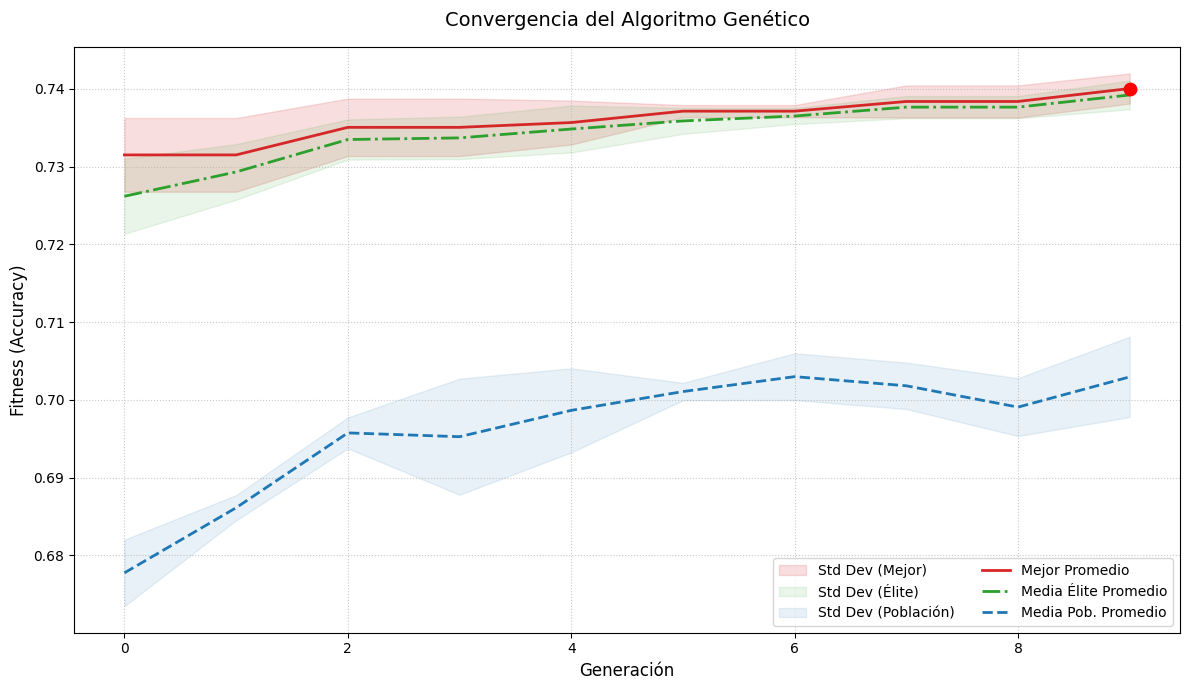

In [ ]:
plot_convergence(
    all_best_hist_ga, all_avg_hist_ga,
    title="Convergencia del Algoritmo Genético",
    show_elite=True
)

### Random Search

In [ ]:
medias_mejor_ejec = []
stds_mejor_ejec = []
medias_pop_ejec = []
stds_pop_ejec = []

for i in range(len(all_best_hist_rs)):
    hist_mejor = [gen[0] for gen in all_best_hist_rs[i]]
    hist_pop = all_avg_hist_rs[i]

    medias_mejor_ejec.append(np.mean(hist_mejor))
    stds_mejor_ejec.append(np.std(hist_mejor))
    medias_pop_ejec.append(np.mean(hist_pop))
    stds_pop_ejec.append(np.std(hist_pop))

df_trayectoria = pd.DataFrame({
    'Media Mejor Fitness Ind.': medias_mejor_ejec,
    'Std Mejor Fitness Ind.': stds_mejor_ejec,
    'Media Avg Fitness Población': medias_pop_ejec,
    'Std Avg Fitness Población': stds_pop_ejec
})
df_trayectoria.index.name = 'Experimento'
df_trayectoria.index += 1

display(df_trayectoria.style.format('{:.4f}'))
print("--- TABLA 1: COMPORTAMIENTO POR EXPERIMENTO ---")

,Media Mejor Fitness Ind.,Std Mejor Fitness Ind.,Media Avg Fitness Población,Std Avg Fitness Población
Experimento,,,,
1,0.7360,0.0021,0.6773,0.0102
2,0.7338,0.0042,0.6795,0.0072
3,0.7343,0.0016,0.6816,0.0074


--- TABLA 1: COMPORTAMIENTO POR EXPERIMENTO ---


In [ ]:
mejores_finales = [all_best_hist_rs[i][-1][0] for i in range(len(all_best_hist_rs))]
pops_finales = [all_avg_hist_rs[i][-1] for i in range(len(all_avg_hist_rs))]

df_finales = pd.DataFrame({
    'Fitness Mejor Individuo': mejores_finales,
    'Avg Fitness Población': pops_finales
})

# Calculamos la desviación entre runs para Random Search
stats_globales = df_finales.describe().loc[['mean', 'std', 'min', 'max']]
stats_globales.index = ['Media Inter-Run', 'Std Inter-Run (Robustez)', 'Mínimo', 'Máximo']
stats_globales_transpuesta = stats_globales.T

display(stats_globales_transpuesta.style.format('{:.4f}'))
print("\n--- TABLA 2 (RS): ROBUSTEZ Y CONSISTENCIA ENTRE EJECUCIONES ---")

,Media Inter-Run,Std Inter-Run (Robustez),Mínimo,Máximo
Fitness Mejor Individuo,0.7369,0.0004,0.7367,0.7373
Avg Fitness Población,0.6823,0.0017,0.6803,0.6833



--- TABLA 2 (RS): ROBUSTEZ Y CONSISTENCIA ENTRE EJECUCIONES ---


In [ ]:
peor_mejor_ind = []
mejor_mejor_ind = []
peor_avg_pop = []
mejor_avg_pop = []
porcentaje_mejora_ind = []
porcentaje_mejora_pop = []

for i in range(len(all_best_hist_rs)):
    hist_mejor = [gen[0] for gen in all_best_hist_rs[i]]
    hist_pop = all_avg_hist_rs[i]

    peor_ind = min(hist_mejor)
    mejor_ind = max(hist_mejor)
    peor_pop = min(hist_pop)
    mejor_pop = max(hist_pop)

    peor_mejor_ind.append(peor_ind)
    mejor_mejor_ind.append(mejor_ind)
    peor_avg_pop.append(peor_pop)
    mejor_avg_pop.append(mejor_pop)

    mejora_ind = ((mejor_ind - peor_ind) / abs(peor_ind)) * 100 if peor_ind != 0 else 0
    porcentaje_mejora_ind.append(mejora_ind)

    mejora_pop = ((mejor_pop - peor_pop) / abs(peor_pop)) * 100 if peor_pop != 0 else 0
    porcentaje_mejora_pop.append(mejora_pop)

df_extremos = pd.DataFrame({
    'Peor (Mejor Fitness Ind.)': peor_mejor_ind,
    'Mejor (Mejor Fitness Ind.)': mejor_mejor_ind,
    '% Mejora (Mejor Fitness Ind.)': porcentaje_mejora_ind,
    'Peor (Avg Fitness Pop.)': peor_avg_pop,
    'Mejor (Avg Fitness Pop.)': mejor_avg_pop,
    '% Mejora (Avg Fitness Pop.)': porcentaje_mejora_pop
})
df_extremos.index.name = 'Experimento'
df_extremos.index += 1

display(df_extremos.style.format({
    'Peor (Mejor Fitness Ind.)': '{:.4f}',
    'Mejor (Mejor Fitness Ind.)': '{:.4f}',
    '% Mejora (Mejor Fitness Ind.)': '{:.2f}%',
    'Peor (Avg Fitness Pop.)': '{:.4f}',
    'Mejor (Avg Fitness Pop.)': '{:.4f}',
    '% Mejora (Avg Fitness Pop.)': '{:.2f}%'
}))
print("\n--- TABLA 3: EXTREMOS POR EXPERIMENTO ---")

,Peor (Mejor Fitness Ind.),Mejor (Mejor Fitness Ind.),% Mejora (Mejor Fitness Ind.),Peor (Avg Fitness Pop.),Mejor (Avg Fitness Pop.),% Mejora (Avg Fitness Pop.)
Experimento,,,,,,
1,0.7298,0.7367,0.94%,0.6526,0.6944,6.41%
2,0.7223,0.7367,1.99%,0.6673,0.6914,3.61%
3,0.7317,0.7373,0.77%,0.6680,0.6930,3.75%



--- TABLA 3: EXTREMOS POR EXPERIMENTO ---


In [ ]:
stats_extremos = df_extremos.describe().loc[['mean', 'std']]
stats_extremos.index = ['Media', 'Std']
stats_extremos_transpuesta = stats_extremos.T

display(stats_extremos_transpuesta.style.format({
    'Media': lambda x: f"{x:.2f}%" if x > 1 or x < -1 else f"{x:.4f}",
    'Std': lambda x: f"{x:.2f}%" if x > 1 or x < -1 else f"{x:.4f}"
}))
print("\n--- TABLA 4: RESUMEN GLOBAL DE EXTREMOS ---")

,Media,Std
Peor (Mejor Fitness Ind.),0.7280,0.0050
Mejor (Mejor Fitness Ind.),0.7369,0.0004
% Mejora (Mejor Fitness Ind.),1.23%,0.6609
Peor (Avg Fitness Pop.),0.6626,0.0087
Mejor (Avg Fitness Pop.),0.6929,0.0015
% Mejora (Avg Fitness Pop.),4.59%,1.58%



--- TABLA 4: RESUMEN GLOBAL DE EXTREMOS ---


In [ ]:
df_perf = pd.DataFrame({
    'Tiempo CPU (s)': cpu_time_rs,
    'Memoria Pico (MB)': memory_rs
})
df_perf.index.name = 'Experimento'
df_perf.index += 1

# Calculamos estadísticas globales y las unimos a la tabla
stats_perf = df_perf.describe().loc[['mean', 'std']]
stats_perf.index = ['Media', 'Std']
tabla_rendimiento = pd.concat([df_perf, stats_perf])

display(tabla_rendimiento.style.format('{:.4f}'))
print("\n--- TABLA 5: RENDIMIENTO COMPUTACIONAL ---")

,Tiempo CPU (s),Memoria Pico (MB)
1,2478.2390,5.7370
2,2260.7401,1.1899
3,2193.4142,1.1648
Media,2310.7977,2.6972
Std,148.8644,2.6326



--- TABLA 5: RENDIMIENTO COMPUTACIONAL ---


In [ ]:
eval_means = [np.mean([item for sublist in tiempos for item in sublist]) for tiempos in all_eval_times_rs]
eval_stds = [np.std([item for sublist in tiempos for item in sublist]) for tiempos in all_eval_times_rs]
eval_maxs = [np.max([item for sublist in tiempos for item in sublist]) for tiempos in all_eval_times_rs]
eval_mins = [np.min([item for sublist in tiempos for item in sublist]) for tiempos in all_eval_times_rs]

# 2. Creamos el DataFrame base con todas las métricas
df_perf_ga = pd.DataFrame({
    'Eval. Media Indiv (s)': eval_means,
    'Eval. Std Indiv (s)': eval_stds,
    'Eval. Máx Indiv (s)': eval_maxs,
    'Eval. Mín Indiv (s)': eval_mins
})

# 3. Configuramos el índice de experimentos
df_perf_ga.index.name = 'Experimento'
df_perf_ga.index += 1

# 4. Calculamos la Media y Desviación Típica global
stats_perf_ga = df_perf_ga.describe().loc[['mean', 'std']]
stats_perf_ga.index = ['Media', 'Std']

# 5. Concatenamos los experimentos con sus estadísticas finales
tabla_rendimiento_ga = pd.concat([df_perf_ga, stats_perf_ga])

# 6. Visualización con formato de 4 decimales
print("\n--- TABLA 6 (RS): RENDIMIENTO COMPUTACIONAL DE EVALUACIÓN DE INDIVIDUOS ---")
display(tabla_rendimiento_ga.style.format('{:.4f}').set_table_styles([
    {'selector': 'tr:nth-child(n+4)', 'props': [('background-color', '#f2f2f2'), ('font-weight', 'bold')]}
]))


--- TABLA 6 (RS): RENDIMIENTO COMPUTACIONAL DE EVALUACIÓN DE INDIVIDUOS ---


,Eval. Media Indiv (s),Eval. Std Indiv (s),Eval. Máx Indiv (s),Eval. Mín Indiv (s)
1,12.3871,6.8427,28.4441,0.8357
2,11.2995,6.3443,29.2157,0.7968
3,10.9628,6.6051,31.4102,0.6850
Media,11.5498,6.5974,29.6900,0.7725
Std,0.7444,0.2493,1.5389,0.0782


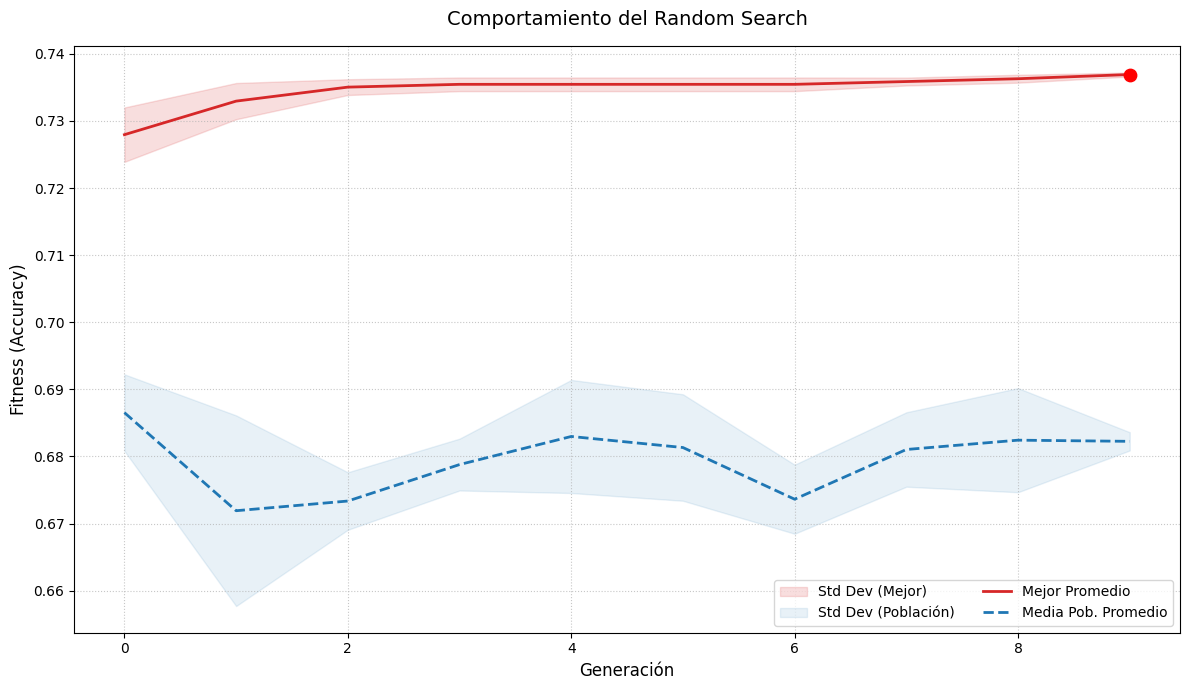

In [ ]:
plot_convergence(
    all_best_hist_rs,
    all_avg_hist_rs,
    title="Comportamiento del Random Search",
    show_elite=False
)